## Results of Host Prediction
### Dataset: EMBL mapping, Vertebrates, Non-IDV

**Models**: FNN, CNN, RNN, LSTM, TF

**Positional Embedding**: Sin-Cos

**Maximum Sequence Length**: 1036

**Classification**: Multi-class

**\# classes**: 5

**\# train samples** = 

**\# validation samples** = 

**\# test samples** = 

In [9]:
import seaborn

In [10]:
seaborn.__version__

'0.13.2'

In [11]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/

In [12]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [13]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv")
input_df = pd.read_csv(input_filepath)

In [14]:
def split_dataset_based_on_column(df, seed, train_proportion, split_input_col=None, label_col=None):
    print(f"Splitting dataset with seed={seed}, train_proportion={train_proportion}, split_input_col={split_input_col}, label_col={label_col}")
    col_values = df[split_input_col].unique().tolist()
    n_col_values = len(col_values)
    print(f"Number of unique values of {split_input_col}={n_col_values}")

    n_train_col_values = int(train_proportion * n_col_values)
    n_test_col_values = n_col_values - n_train_col_values

    print(f"Expected number of train {split_input_col} values = {n_train_col_values}")
    print(f"Expected number of test {split_input_col} values = {n_test_col_values}")

    np.random.seed(seed)
    train_col_values = np.random.choice(col_values, size=n_train_col_values, replace=False)
    test_col_values = list(set(col_values) - set(train_col_values))

    print(f"Number of train {split_input_col} values = {len(train_col_values)}")
    print(f"Number of test {split_input_col} values = {len(test_col_values)}")

    train_df = df[df[split_input_col].isin(train_col_values)]
    test_df = df[df[split_input_col].isin(test_col_values)]

    print(f"Size of train_dataset = {train_df.shape}; number of unique labels = {train_df[label_col].nunique()}")
    print(f"Size of test_dataset = {test_df.shape}; number of unique labels = {test_df[label_col].nunique()}")
    return train_df, test_df

def split_dataset_stratified(df, seed, train_proportion, stratify_col=None):
    print(f"Splitting dataset with seed={seed}, train_proportion={train_proportion}, stratify_col={stratify_col}")
    train_df, test_df = train_test_split(df, train_size=train_proportion, random_state=seed, stratify=df[stratify_col])
    print(f"Size of train_dataset = {train_df.shape}")
    print(f"Size of test_dataset = {test_df.shape}")
    return train_df, test_df

In [15]:
input_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
9635,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,False
9636,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,False
9637,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,False
9638,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,False


In [5]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        df.fillna(0, inplace=True)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

In [16]:
train_df, test_df = split_dataset_based_on_column(input_df, 12612648, .8, split_input_col="virus_genus_tax_name", label_col="virus_host_species_tax_id")

Splitting dataset with seed=12612648, train_proportion=0.8, split_input_col=virus_genus_tax_name, label_col=virus_host_species_tax_id
Number of unique values of virus_genus_tax_name=141
Expected number of train virus_genus_tax_name values = 112
Expected number of test virus_genus_tax_name values = 29
Number of train virus_genus_tax_name values = 112
Number of test virus_genus_tax_name values = 29
Size of train_dataset = (7238, 10); number of unique labels = 8
Size of test_dataset = (2402, 10); number of unique labels = 8


In [24]:
def macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    raw_results = []
    itr_col = "itr"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        raw_df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {raw_df.shape}")
        raw_df = raw_df[["protein_id_name", itr_col, y_true_col] + classes].merge(input_df[["proteome_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_genus_tax_name"]], on="protein_id_name", how="left")
        raw_df["model"] = model
        raw_results.append(raw_df)
        df = raw_df[classes + ["proteome_id", "y_true", "itr"]]
        df = df.groupby(["proteome_id", "y_true", "itr"]).agg("mean").reset_index()
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    axs[1].set_title("BVBRC Proteome | Virus Genus Split | Host Species", size=18)
    sns.move_legend(axs[1], "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(axs[1].get_legend().get_texts(), fontsize=18)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes) - 1):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return pd.concat(raw_results)

In [18]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)

    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=18)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    axs[1].set_title("BVBRC Proteins | Virus Genus Split | Host Species", size=18)
    sns.move_legend(axs[1], "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(axs[1].get_legend().get_texts(), fontsize=18)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes) - 1):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

Read output BLAST = (2402, 14)
Read output ProtT5 = (4156, 11)
Read output HAVEN = (8203, 11)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set

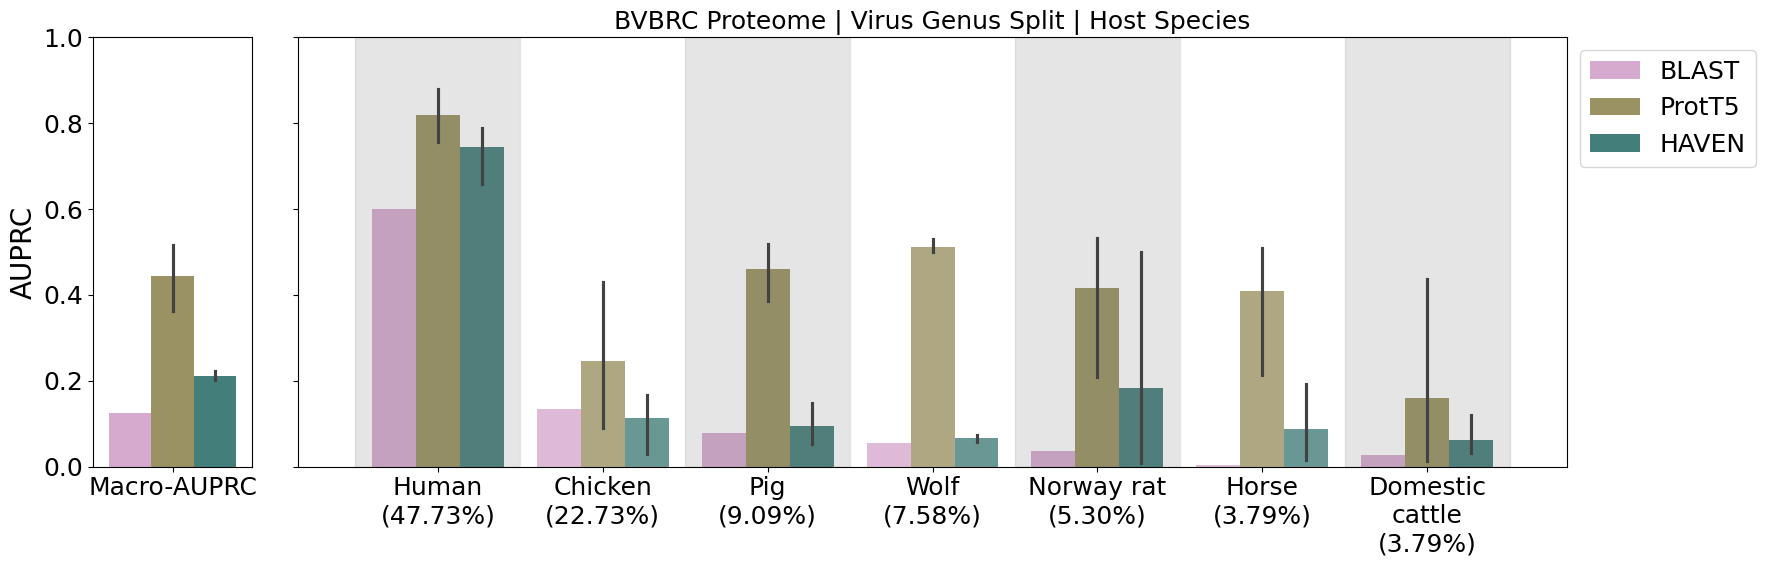

In [26]:
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "ProtT5": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260611/host_multi/virus_genus_split/external/bvbrc_prott5_prot_t5_base_mt_uniref50_msl2048_fnn_2l_d768_lr3e-4_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260518/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_virus_genus_split_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4_output.csv"),
    
}

classes = ["Human", "Chicken", "Pig", "Domestic cattle", "Norway rat", "Horse", "Wolf", "Boa"]
auprc_results_df = macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/20260901/host_multi_all_models_bvbrc_genus_proteome_auprc.pdf"))

In [31]:
def classwise_probability_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    id_col="proteome_id"
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    print(classes)
    dfs = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        df["model"] = model
        df = df[["protein_id_name", itr_col, y_true_col] + classes].merge(input_df[["proteome_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_genus_tax_name"]], on="protein_id_name", how="left")

        itrs = df[itr_col].unique()
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            df_itr["model"] = model
            df_itr[itr_col] = itr
            melted_df = df_itr[classes + [id_col, y_true_col, itr_col, "model"]].melt(id_vars=[id_col, y_true_col, itr_col, "model"], var_name="class", value_name="probability")
            melted_df["true_class_probability"] = melted_df.apply(lambda x: x["class"] == x[y_true_col], axis=1)
            dfs.append(melted_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    df = pd.concat(dfs, ignore_index=True)
    df.replace({"class": metadata_formatted}, inplace=True)
    models = list(df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams.update({'font.size': 16})
    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=False, sharey=False)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    ax = axs[0]
    sns.boxplot(data=df, x="class", y="probability", hue="model", #style="true_class_probability",
                palette=color_palette, ax=ax)
    ax.axhline((1/len(classes)), ls="--")
    ax.set_ylim(0.0, 1)
    ax.set_ylabel("Predicted Probability", size=18)
    ax.set_xlabel("", size=0, labelpad=0)
    ax.set_title("BVBRC Proteome | Virus Genus Split | Host Species", size=16)
    sns.move_legend(ax, "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(ax.get_legend().get_texts(), fontsize=16)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(ax, axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)


    ax = axs[1]
    sns.boxplot(data=df[df["true_class_probability"] == True], x="class", y="probability", hue="model", #style="true_class_probability",
                palette=color_palette, ax=ax)
    ax.axhline((1/len(classes)), ls="--")
    ax.set_ylim(0.0, 1)
    ax.set_ylabel("Predicted Probability\nfor Ground-truth labels", size=18)
    ax.set_xlabel("", size=0, labelpad=0)
    #ax.set_title("UniRef90 Proteins | Virus Genus Split | Host Species", size=16)
    sns.move_legend(ax, "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(ax.get_legend().get_texts(), fontsize=16)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(ax, axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=1024)
    plt.show()
    return df

['Human', 'Chicken', 'Pig', 'Domestic cattle', 'Norway rat', 'Horse', 'Wolf', 'Boa']
Read output BLAST = (2402, 14)
Read output ProtT5 = (4156, 11)


/tmp/ipykernel_1290987/1683283933.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr["model"] = model
/tmp/ipykernel_1290987/1683283933.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr[itr_col] = itr
/tmp/ipykernel_1290987/1683283933.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

Read output HAVEN = (8203, 11)


/tmp/ipykernel_1290987/1683283933.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr["model"] = model
/tmp/ipykernel_1290987/1683283933.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr[itr_col] = itr
/tmp/ipykernel_1290987/1683283933.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

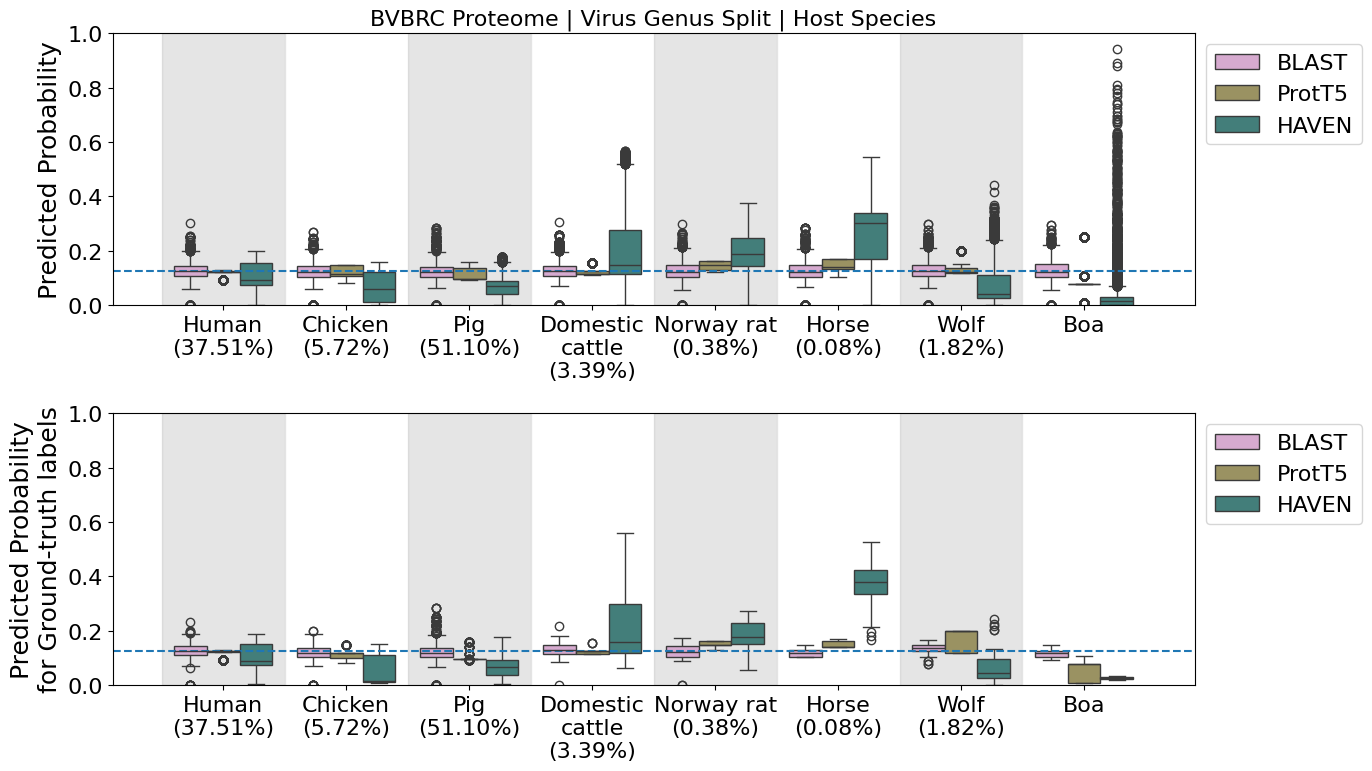

In [32]:
y = classwise_probability_analysis(output_filepaths, classes, figure_output_filepath=os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/20260901/host_multi_all_models_bvbrc_genus_proteome_class_probabilities.pdf"))

In [36]:
y

,proteome_id,y_true,itr,model,class,probability,true_class_probability
0,KM102979,Pig,0,BLAST,Human (37.51%),0.080774,False
1,KM102979,Pig,0,BLAST,Human (37.51%),0.102501,False
2,KM102979,Pig,0,BLAST,Human (37.51%),0.104481,False
3,KM102979,Pig,0,BLAST,Human (37.51%),0.146325,False
4,KM102979,Pig,0,BLAST,Human (37.51%),0.107618,False
...,...,...,...,...,...,...,...
118083,NaN,Pig,2,HAVEN,Boa,0.310485,False
118084,NaN,Human,2,HAVEN,Boa,0.019794,False
118085,NaN,Pig,2,HAVEN,Boa,0.676073,False
118086,NaN,Human,2,HAVEN,Boa,0.042187,False


In [46]:
def combine_output_files(output_filepath_template, itrs, output_filename):
    dfs = []
    for itr in itrs:
        df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", output_filepath_template.format(itr=itr)), index_col=0)
        df["itr"] = int(itr)
        dfs.append(df)
    pd.concat(dfs).to_csv(output_filename)

In [9]:
combine_output_files(os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_itr{itr}_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output_itr0.csv"),
                     [1, 2, 3],
                    os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output.csv"))

In [33]:
def analyse_virus_genus_predictions_per_proteome(raw_results_df, virus_genus, model_name):
    plot_df = raw_results_df[(raw_results_df["virus_genus_tax_name"] == virus_genus) & (raw_results_df["model"] == model_name)]
    print(plot_df.shape)
    proteomes = plot_df["proteome_id"].unique()
    n_proteomes = len(proteomes)
    n_proteins = plot_df["protein"].value_counts().shape[0]
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams.update({'font.size': 10})
    fig, axs = plt.subplots(n_proteomes, 1, figsize=(8, n_proteomes*n_proteins/2), sharex=True, sharey=False)
    
    for i, proteome in enumerate(proteomes):
        ax = axs[i]
        y_true_class = plot_df[plot_df["proteome_id"] == proteome]["y_true"].unique()[0]
        heatmap_df = plot_df[plot_df["proteome_id"] == proteome]
        itr = heatmap_df["itr"].unique()[0]
        heatmap_df = heatmap_df[heatmap_df["itr"] == itr][classes + ["protein"]].set_index("protein")
        heatmap_df.fillna(0, inplace=True)
        sns.heatmap(heatmap_df, ax=ax, linewidth=2,
                    annot=True, fmt=".2f",
                    vmin=0, vmax=1,
                    cmap="crest", alpha=.9,
                   cbar_kws={"aspect": 10})
        ax.set_title(f"Proteome:{proteome}\nHost:{y_true_class}", size=10)
        ax.set(xlabel="", ylabel="")

(20, 16)


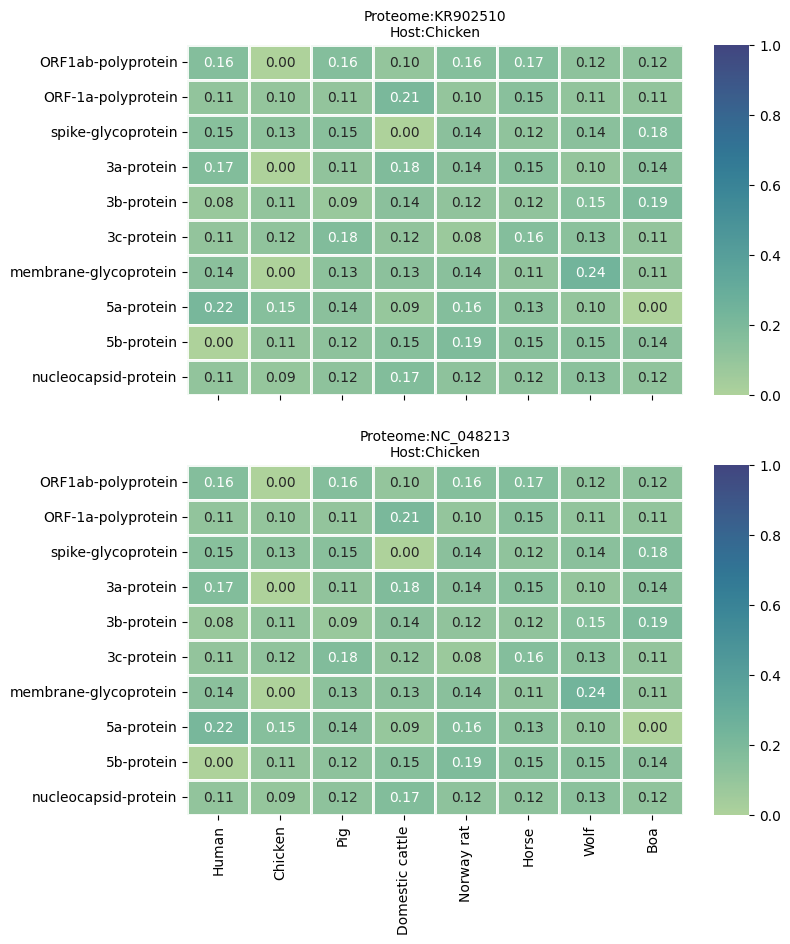

In [44]:
virus_genus = "Gammacoronavirus"
model_name = "BLAST"
analyse_virus_genus_predictions_per_proteome(auprc_results_df, virus_genus, model_name)

(15, 16)


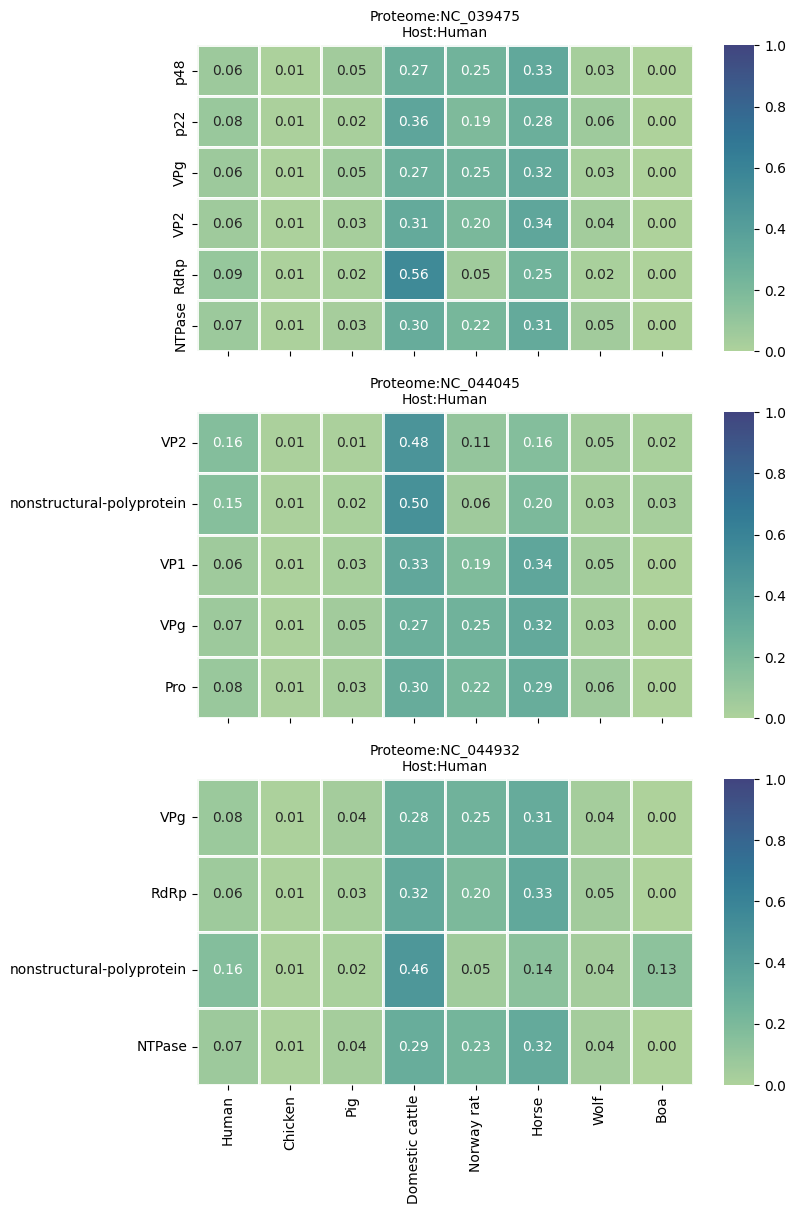

In [48]:
virus_genus = "Norovirus"
model_name = "HAVEN"
analyse_virus_genus_predictions_per_proteome(auprc_results_df, virus_genus, model_name)

In [45]:
set(auprc_results_df[auprc_results_df["model"] == "HAVEN"]["virus_genus_tax_name"].unique()).intersection(auprc_results_df[auprc_results_df["model"] == "BLAST"]["virus_genus_tax_name"].unique())

{'Alphapapillomavirus',
 'Amaruvirus',
 'Asfivirus',
 'Avisivirus',
 'Barthadenovirus',
 'Betatorquevirus',
 'Bostovirus',
 'Chipapillomavirus',
 'Circovirus',
 'Felismacovirus',
 'Kappatorquevirus',
 'Mardivirus',
 'Nicoomyvirus',
 'Orbivirus',
 'Protoambidensovirus',
 'Sicinivirus'}